# 01: Auditoria de dados e análise de sinal

Este notebook é a primeira etapa do pipeline: **antes de treinar qualquer modelo**, auditamos
estatisticamente os dados fornecidos no case, em vez de assumir que o enunciado descreve
exatamente o que os arquivos contêm. Ver [`docs/01_interpretacao_problema.md`](../docs/01_interpretacao_problema.md)
para a discussão completa e [`docs/07_perguntas_ao_cliente.md`](../docs/07_perguntas_ao_cliente.md)
para o que não pôde ser resolvido só com os dados.

Todo o código chamado aqui vive em `src/pdm/`; este notebook é uma camada de visualização
sobre a mesma auditoria que roda via `python -m pdm.cli audit`, não uma implementação paralela.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from pdm.config import load_config
from pdm.data.loader import load_sensor_dataset
from pdm.data.audit import run_audit

mpl.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

cfg = load_config()
dataset = load_sensor_dataset(cfg)
print(f"{dataset.n_windows} janelas, {dataset.window_len} amostras por janela, "
      f"{dataset.sample_rate_hz} Hz -> {dataset.window_len / dataset.sample_rate_hz * 1000:.0f} ms por janela")
print("Sensores:", dataset.sensor_names)
print("Classes:", dataset.class_names())


50000 janelas, 200 amostras por janela, 10000 Hz -> 20 ms por janela
Sensores: ['Dados_1', 'Dados_2', 'Dados_3', 'Dados_4', 'Dados_5']
Classes: ['Classe A', 'Classe B', 'Classe C', 'Classe D', 'Classe E']


In [2]:
report = run_audit(dataset, cfg)

print("Balanceamento:", report.class_balance_verdict)
print()
print("Contiguidade das linhas:", report.row_contiguity.verdict)
print()
print("Simultaneidade entre sensores:", report.inter_sensor_simultaneity.verdict)
print()
for name, a in report.sensor_audits.items():
    print(f"{name}: {a.verdict}")
print()
print("Sensores recomendados para o modelo:", report.recommended_sensors)


Balanceamento: perfectly balanced across classes; unlikely to occur naturally on a factory floor; treat as a curated/synthetic sample and re-evaluate under a realistic class prior before deployment (see evaluation/imbalance.py)

Contiguidade das linhas: rows are independent/shuffled windows; no evidence of a continuous underlying recording

Simultaneidade entre sensores: cannot verify exact timestamps (none provided); row-wise RMS envelopes co-vary across sensors, consistent with; but not proof of; simultaneous acquisition

Dados_1: carries class-discriminative information; retained
Dados_2: carries class-discriminative information; retained
Dados_3: carries class-discriminative information; retained
Dados_4: stuck at (near-)constant value; no information, likely a dead/miswired sensor
Dados_5: statistically indistinguishable from white noise across classes; excluded

Sensores recomendados para o modelo: ['Dados_1', 'Dados_2', 'Dados_3']


## Balanceamento de classes

As 5 classes vêm perfeitamente balanceadas, um padrão que não costuma ocorrer numa planta real (ver `evaluation/imbalance.py` para a reavaliação sob um prior realista).

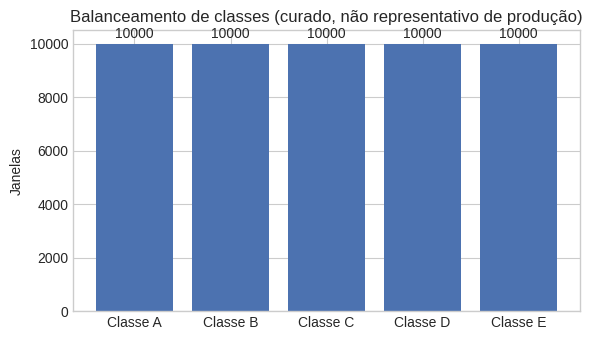

In [3]:
classes, counts = np.unique(dataset.labels, return_counts=True)
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(classes, counts, color="#4C72B0")
ax.set_ylabel("Janelas")
ax.set_title("Balanceamento de classes (curado, não representativo de produção)")
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, c + 200, str(c), ha="center")
plt.tight_layout()
plt.show()


## A coluna fantasma em `Dados_1`, `Dados_2` e `Dados_3`

Esses três arquivos têm 201 colunas em vez das 200 esperadas (20 ms a 10 kHz). O `loader`
(`src/pdm/data/loader.py`) já descartou essa 201ª coluna antes de expor `dataset.sensors`,
mas o valor bruto fica preservado em `dataset.ghost_columns` para essa auditoria.


In [4]:
for name, ghost in dataset.ghost_columns.items():
    non_nan_idx = np.where(~np.isnan(ghost))[0]
    print(f"{name}: {len(non_nan_idx)} valor(es) não-NaN em {len(ghost)} linhas "
          f"-> índice(s) {non_nan_idx.tolist()}, valor(es) {ghost[non_nan_idx].tolist()}, "
          f"classe(s) {dataset.labels[non_nan_idx].tolist()}")


Dados_1: 1 valor(es) não-NaN em 50000 linhas -> índice(s) [49708], valor(es) [2.0], classe(s) ['Classe C']
Dados_2: 1 valor(es) não-NaN em 50000 linhas -> índice(s) [1464], valor(es) [4.0], classe(s) ['Classe A']
Dados_3: 1 valor(es) não-NaN em 50000 linhas -> índice(s) [31977], valor(es) [2.0], classe(s) ['Classe A']


## Saturação e o filtro de Hampel

Os três sensores reais têm um punhado de amostras exatamente no fundo de escala (±5 V,
compatível com o ADC de um condicionador de sinal típico). `preprocessing/cleaning.py`
usa um filtro de Hampel (mediana + MAD local) para tratar esses picos sem descartar a
janela inteira. Abaixo, um exemplo real de antes/depois.


Dados_1: 9 janela(s) tocam o limiar de saturação de 5.0 V


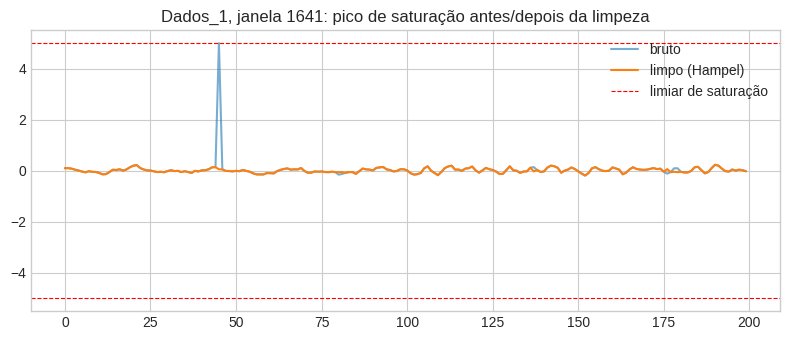

In [5]:
from pdm.preprocessing.cleaning import SensorCleaner

sensor = "Dados_1"
raw = dataset.sensors[sensor]
sat_threshold = cfg.cleaning["saturation_abs_threshold"]
sat_rows = np.where(np.any(np.abs(raw) >= sat_threshold, axis=1))[0]
print(f"{sensor}: {len(sat_rows)} janela(s) tocam o limiar de saturação de {sat_threshold} V")

cleaner = SensorCleaner(**{k: cfg.cleaning[k] for k in
                            ["saturation_abs_threshold", "hampel_window", "hampel_n_sigmas",
                             "silent_window_std_percentile"]})
cleaned = cleaner.fit_transform(raw)

example = sat_rows[0]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(raw[example], label="bruto", alpha=0.6)
ax.plot(cleaned[example], label="limpo (Hampel)", linewidth=1.5)
ax.axhline(sat_threshold, color="red", linestyle="--", linewidth=0.8, label="limiar de saturação")
ax.axhline(-sat_threshold, color="red", linestyle="--", linewidth=0.8)
ax.set_title(f"{sensor}, janela {example}: pico de saturação antes/depois da limpeza")
ax.legend()
plt.tight_layout()
plt.show()


## Janelas quase silenciosas

Uma pequena fração das janelas de cada sensor real tem energia muito baixa, possivelmente
um instante de folga do sensor, ou a máquina genuinamente parada. Essas janelas são
sinalizadas (`is_silent`), não descartadas nem tratadas como uma predição confiável.


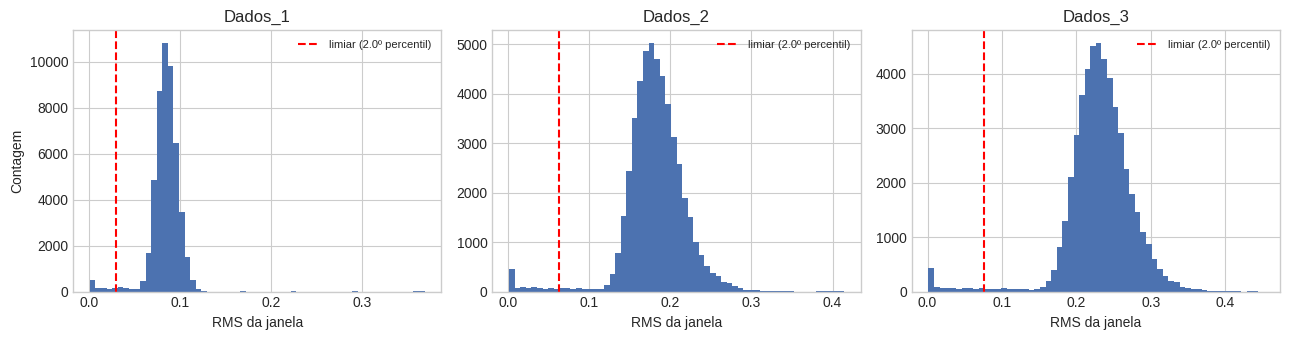

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=False)
for ax, name in zip(axes, ["Dados_1", "Dados_2", "Dados_3"]):
    row_std = dataset.sensors[name].std(axis=1)
    threshold = np.percentile(row_std, cfg.cleaning["silent_window_std_percentile"])
    ax.hist(row_std, bins=60, color="#4C72B0")
    ax.axvline(threshold, color="red", linestyle="--", label=f"limiar ({cfg.cleaning['silent_window_std_percentile']}º percentil)")
    ax.set_title(name)
    ax.set_xlabel("RMS da janela")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Contagem")
plt.tight_layout()
plt.show()


## Os dois sensores excluídos: `Dados_4` (travado) e `Dados_5` (ruído)

A auditoria decide a exclusão com testes estatísticos (Kruskal-Wallis + teste de permutação
de informação mútua), não por inspeção visual, mas visualizar confirma por que os testes
dão esse resultado.

Referências: teste de Kruskal-Wallis (Kruskal & Wallis, 1952, *Use of Ranks in One-Criterion Variance Analysis*); teste de permutação para significância de informação mútua segue o procedimento padrão de embaralhar o rótulo e recalcular a estatística (ver também Kraskov, Stögbauer & Grassberger, 2004, para estimadores de MI contínua).


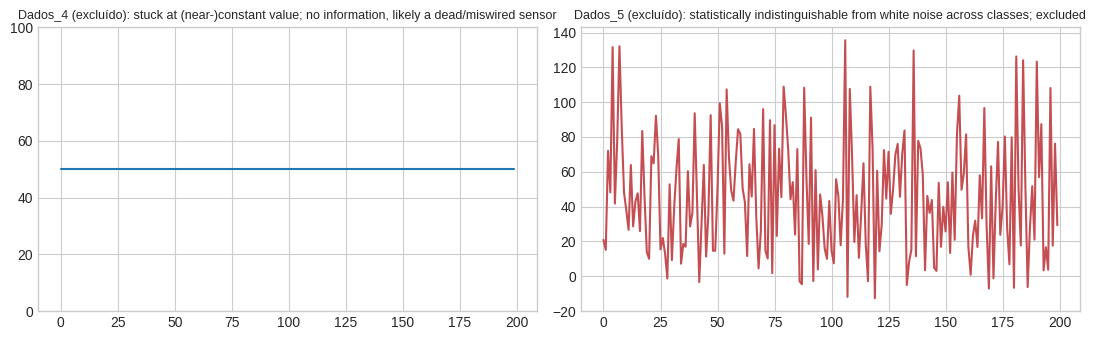

Dados_4: p(Kruskal-Wallis)=1, p(permutação)=0.55, razão de valores únicos=1.00e-07
Dados_5: p(Kruskal-Wallis)=0.279, p(permutação)=1, autocorrelação lag-1 por classe={'Classe A': -0.007, 'Classe B': -0.004, 'Classe C': -0.005, 'Classe D': -0.006, 'Classe E': -0.004}


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(dataset.sensors["Dados_4"][0])
axes[0].set_title(f"Dados_4 (excluído): {report.sensor_audits['Dados_4'].verdict}", fontsize=9)
axes[0].set_ylim(0, 100)

axes[1].plot(dataset.sensors["Dados_5"][0], color="#C44E52")
axes[1].set_title(f"Dados_5 (excluído): {report.sensor_audits['Dados_5'].verdict}", fontsize=9)
plt.tight_layout()
plt.show()

a4, a5 = report.sensor_audits["Dados_4"], report.sensor_audits["Dados_5"]
print(f"Dados_4: p(Kruskal-Wallis)={a4.kruskal_wallis_p:.3g}, p(permutação)={a4.permutation_test_p:.3g}, "
      f"razão de valores únicos={a4.unique_value_ratio:.2e}")
print(f"Dados_5: p(Kruskal-Wallis)={a5.kruskal_wallis_p:.3g}, p(permutação)={a5.permutation_test_p:.3g}, "
      f"autocorrelação lag-1 por classe={ {k: round(v,3) for k,v in a5.lag1_autocorr_by_class.items()} }")


## Conteúdo espectral por classe: por que a hipótese de vibração/corrente

O espectro médio de cada sensor retido varia visivelmente por classe, com energia concentrada
em bandas específicas entre ~400 Hz e ~1,7 kHz, consistente com harmônicos de um motor
elétrico girante sob diferentes condições, não com ruído genérico. Ver
`docs/01_interpretacao_problema.md`, seção 1.4, para a discussão completa (e suas limitações).


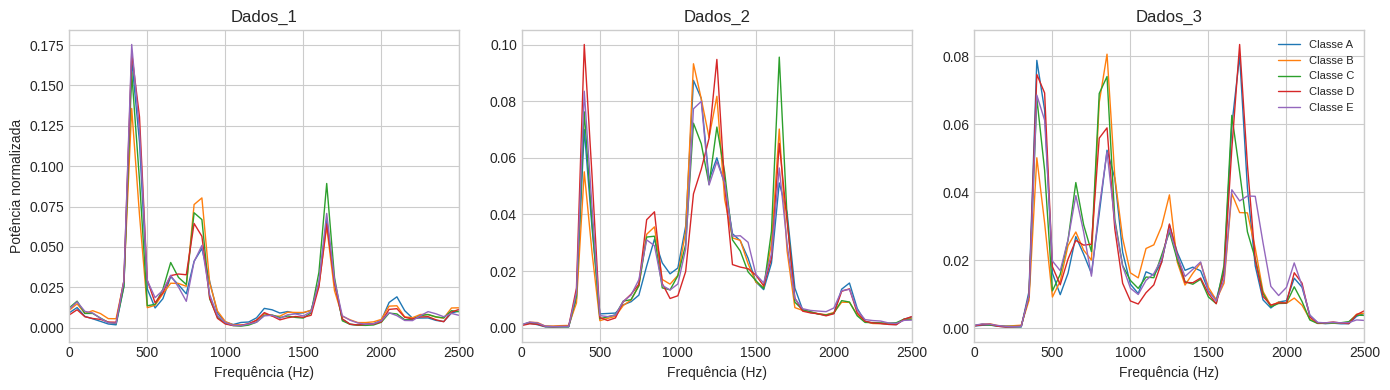

In [8]:
from pdm.preprocessing.dsp import detrend, hann_window

fs = dataset.sample_rate_hz
window_len = dataset.window_len
freqs = np.fft.rfftfreq(window_len, 1 / fs)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for ax, name in zip(axes, report.recommended_sensors):
    matrix = dataset.sensors[name]
    for cls in dataset.class_names():
        rows = matrix[dataset.labels == cls]
        conditioned = np.apply_along_axis(lambda r: hann_window(detrend(r)), 1, rows)
        power = np.abs(np.fft.rfft(conditioned, axis=1)) ** 2
        mean_power = power.mean(axis=0)
        ax.plot(freqs, mean_power / mean_power.sum(), label=cls, linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Frequência (Hz)")
    ax.set_xlim(0, 2500)
axes[0].set_ylabel("Potência normalizada")
axes[-1].legend(fontsize=8)
plt.tight_layout()
plt.show()


## Escalograma wavelet de exemplo

Uma janela por classe, sensor `Dados_2` (o de maior amplitude entre os três retidos).

Referências: transformada wavelet contínua (Daubechies, 1992, *Ten Lectures on Wavelets*); a versão *synchrosqueezed* usada opcionalmente em `features/wavelet.py` segue Daubechies, Lu & Wu (2011, *Synchrosqueezed Wavelet Transforms*).


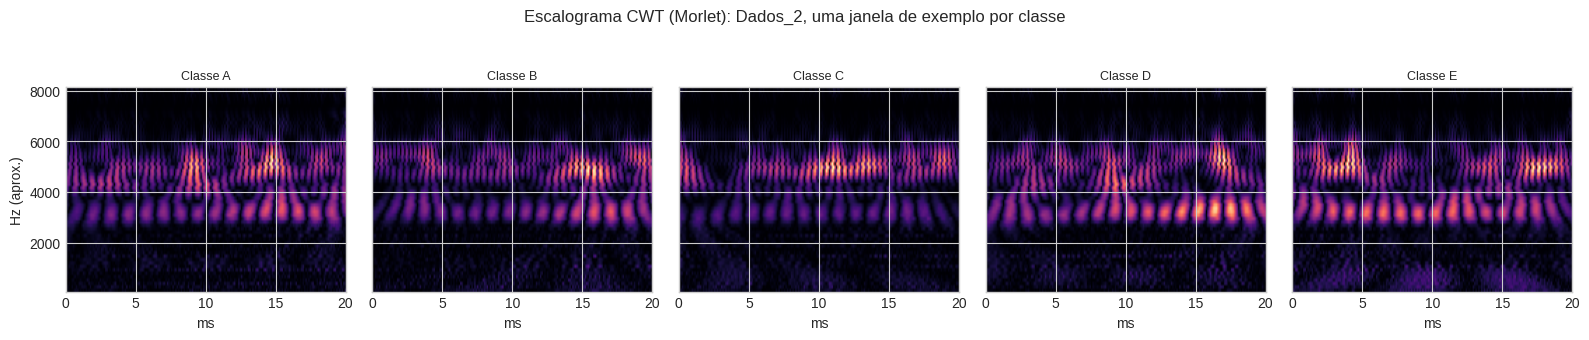

In [9]:
import pywt

sensor = "Dados_2"
scales = np.geomspace(1, 128, 60)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharey=True)
for ax, cls in zip(axes, dataset.class_names()):
    idx = np.where(dataset.labels == cls)[0][0]
    row = dataset.sensors[sensor][idx]
    coeffs, cwt_freqs = pywt.cwt(row, scales, "morl", sampling_period=1 / fs)
    ax.imshow(np.abs(coeffs), aspect="auto", extent=[0, window_len / fs * 1000, cwt_freqs[-1], cwt_freqs[0]],
              cmap="magma")
    ax.set_title(cls, fontsize=9)
    ax.set_xlabel("ms")
axes[0].set_ylabel("Hz (aprox.)")
plt.suptitle(f"Escalograma CWT (Morlet): {sensor}, uma janela de exemplo por classe", y=1.05)
plt.tight_layout()
plt.show()


## Conclusão desta etapa

- Sensores retidos para modelagem: **Dados_1, Dados_2, Dados_3** (decisão estatística, não visual).
- Sensores excluídos: **Dados_4** (travado) e **Dados_5** (ruído branco em relação às classes).
- A coluna 201 de `Dados_1-3` é um artefato de exportação, descartada com validação.
- O conteúdo espectral varia por classe de forma consistente com um motor elétrico girante,
  mas a grandeza física exata (vibração vs. corrente) e a unidade de engenharia permanecem
  como pergunta em aberto para o cliente (`docs/07_perguntas_ao_cliente.md`).

Próxima etapa: [`02_feasibility_and_evaluation.ipynb`](02_feasibility_and_evaluation.ipynb):
viabilidade de modelagem, avaliação completa e explicabilidade.
